In [3]:
import sys
print(sys.executable)

import yaml
print(yaml.__file__)

/home/lhe09/miniconda3/envs/first/bin/python
/home/lhe09/miniconda3/envs/first/lib/python3.10/site-packages/yaml/__init__.py


In [ ]:
#import yaml
import pandas as pd

#with open("../configs.yaml") as f:
#    cfg = yaml.safe_load(f)

# configs.yaml을 어디서든 열수 있는 프로젝트 root 기준으로 경로 만드는 법
from pathlib import Path
import yaml

ROOT = Path().resolve().parent   # notebooks 상위
config_path = ROOT / "configs.yaml"

with open(config_path) as f:
    cfg = yaml.safe_load(f)
# --------------------------------------
# 1. Load Meta Data
# --------------------------------------
label_df = pd.read_csv(cfg["data"]["train_label_csv"])
desc_df = pd.read_csv(cfg["data"]["train_desc_csv"])

print("Shape:", label_df.shape)

Shape: (48692, 7)


In [8]:
label_df.groupby(
    ["study_id", "series_id", "instance_number"]
).size().describe()

count    24546.000000
mean         1.983704
std          1.251497
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         10.000000
dtype: float64

In [12]:
import os

print(cfg["data"]["train_images_root"])
print(os.path.exists(cfg["data"]["train_images_root"]))

/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images
True


In [ ]:
import os

base = "/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images"

study_id = 4003253
series_id = 702807833

path = os.path.join(base, str(study_id), str(series_id))

files = [f for f in os.listdir(path) if f.endswith(".dcm")]

print("slice 개수:", len(files))


slice 개수: 15


TypeError: 'str' object is not callable

In [19]:
import pydicom

path = "/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images/4003253/702807833"

import os
f = os.listdir(path)[0]

dcm = pydicom.dcmread(os.path.join(path, f))

print(dcm)

Dataset.file_meta -------------------------------
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 4003253.1.1
(0002,0010) Transfer Syntax UID                 UI: RLE Lossless
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: 4003253.1.1
(0008,0023) Content Date                        DA: '20240503'
(0008,0033) Content Time                        TM: '223718.007977'
(0008,103E) Series Description                  LO: 'T2'
(0010,0020) Patient ID                          LO: '4003253'
(0018,0050) Slice Thickness                     DS: '4.0'
(0018,0088) Spacing Between Slices              DS: '4.8'
(0018,5100) Patient Position                    CS: 'HFS'
(00

In [ ]:
cycle error 
< 1.0 px  매우 좋음
< 0.5 px  strong
< 0.2 px  매우 안정

In [ ]:
failed_case 226개 발생() - 640, 608이라는 다른 해상도가 존재하였음
실패케이스만 다시 돌림(35개 series)

[INFO] existing rows: 664944
[INFO] new rows: 10796
[INFO] total saved rows: 675740

SyntaxError: invalid decimal literal (4170373295.py, line 1)

In [ ]:
GT anchor
   ↓
Self-supervised registration
   ↓
Cycle consistency filtering
   ↓
Dense pseudo-label
   ↓
ROI multi-slice dataset

In [ ]:
# 코드 모두 수정함
# propagation.csv
# load dicom series
# 좌표별 ROI crop
# 9 slice stack
# disc별 sample 생성
# .pt 저장

In [1]:
# propagated_lavels.csv 확인(pre_process_all.py 확인(roi전))
import pandas as pd

df = pd.read_csv("../outputs/labels/propagated_labels.csv")
print(df.columns)
print(df.head())

Index(['study_id', 'series_id', 'anchor_instance', 'instance_number',
       'num_points', 'x_coords', 'y_coords', 'cycle_error', 'valid'],
      dtype='object')
   study_id  series_id  anchor_instance  instance_number  num_points  \
0   4003253  702807833                8                1           5   
1   4003253  702807833                8                2           5   
2   4003253  702807833                8                3           5   
3   4003253  702807833                8                4           5   
4   4003253  702807833                8                5           5   

                                            x_coords  \
0  [322.8570861816406, 320.5860595703125, 323.057...   
1  [322.85577392578125, 320.5853271484375, 323.05...   
2  [322.8543701171875, 320.5846252441406, 323.054...   
3  [322.85284423828125, 320.58392333984375, 323.0...   
4  [322.8512268066406, 320.5832214355469, 323.051...   

                                            y_coords  cycle_error  v

In [ ]:
import ast

sample = df.iloc[0]

x = ast.literal_eval(sample["x_coords"])
y = ast.literal_eval(sample["y_coords"])

print(len(x), len(y))
# num_points와 길이가 일치해야함.

5 5


In [ ]:
# 한 series가 slice 몇개를 가지고 있는지 확인
df.groupby(["study_id","series_id"]).size().describe()

count    6291.000000
mean      107.413766
std       114.076464
min         5.000000
25%        25.000000
50%        68.000000
75%       147.000000
max      1680.000000
dtype: float64

In [ ]:
# cycle_error상태 확인
df["cycle_error"].describe()
# 확인사항(평균이 너무 크지 않을 것!, 5이상 튀는 아이가 있는지 확인 할 것!)

# count(row) 676740 # slice * anchor(6291개의 series, 평균 107개의 slice)

# cycel_error(anchor-> slice -> anchor)의 의미
# < 0.05 매우 좋음
# < 0.1 정상
# < 0.3 borderline
# > 0.5 bad

count    675740.000000
mean          0.067478
std           0.083368
min           0.000000
25%           0.014848
50%           0.037468
75%           0.098989
max           1.041625
Name: cycle_error, dtype: float64

In [ ]:
# cycle_error valid 비율 확인
df["valid"].value_counts(normalize=True)
# valid 1 -> 95%이상이여야 정상

# 보통 propagation에서 valid ratio의 의미
# 70% 보통
# 80~90% 좋음
# > 90% 매우 좋음

valid
1    0.954071
0    0.045929
Name: proportion, dtype: float64

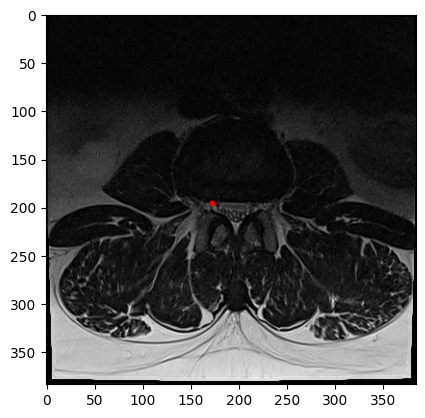

In [12]:
# series 하나 골라서 무작위 시각화
import os
import ast
import pydicom
import matplotlib.pyplot as plt
import yaml

with open("../configs.yaml") as f:
    cfg = yaml.safe_load(f)

ROOT = cfg["data"]["train_images_root"]

sample = df.iloc[1050]

x = ast.literal_eval(sample["x_coords"])
y = ast.literal_eval(sample["y_coords"])

img_path = os.path.join(
    ROOT,
    str(sample.study_id),
    str(sample.series_id),
    f"{sample.instance_number}.dcm"
)

dcm = pydicom.dcmread(img_path)
img = dcm.pixel_array

plt.imshow(img, cmap="gray")
plt.scatter(x, y, c="r", s=10)
plt.show()

In [14]:
sample = df.iloc[1050]

print(sample)

study_id                       7143189
series_id                   1951927562
anchor_instance                     17
instance_number                      7
num_points                           1
x_coords           [172.0594482421875]
y_coords           [195.3032684326172]
cycle_error                   0.092315
valid                                1
Name: 1050, dtype: object


In [18]:
import pandas as pd
df = pd.read_csv("/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train.csv")
print(df.columns)

Index(['study_id', 'spinal_canal_stenosis_l1_l2',
       'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4',
       'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1',
       'left_neural_foraminal_narrowing_l1_l2',
       'left_neural_foraminal_narrowing_l2_l3',
       'left_neural_foraminal_narrowing_l3_l4',
       'left_neural_foraminal_narrowing_l4_l5',
       'left_neural_foraminal_narrowing_l5_s1',
       'right_neural_foraminal_narrowing_l1_l2',
       'right_neural_foraminal_narrowing_l2_l3',
       'right_neural_foraminal_narrowing_l3_l4',
       'right_neural_foraminal_narrowing_l4_l5',
       'right_neural_foraminal_narrowing_l5_s1',
       'left_subarticular_stenosis_l1_l2', 'left_subarticular_stenosis_l2_l3',
       'left_subarticular_stenosis_l3_l4', 'left_subarticular_stenosis_l4_l5',
       'left_subarticular_stenosis_l5_s1', 'right_subarticular_stenosis_l1_l2',
       'right_subarticular_stenosis_l2_l3',
       'right_subarticular_stenosis_l3_l4',
 

In [ ]:
# 이후 bulid_roi_dataset.py로 roi 이미지를 잘라서 pt를 만듦
# progatated slice모두를 사용하는것이 아니라 center_idx를 가지고와 주변 9개의 slice만 사용하여 disc 중심의 ROI crop을 생성

In [ ]:
# 이후 ResNet 3D or ViT
# attention vs propagated coord 
# distance

In [ ]:
# build_roi_dataset.py는 6279개의 series그룹이 돌아감.

In [19]:
import torch

x = torch.load("/home/lhe09/projects/rsna_spine/outputs/roi_dataset/100.pt")

print(x["image"].shape)
print(x["label"])
print(x["level"])
print(x["coord"])

torch.Size([9, 224, 224])
tensor([0, 0, 0, 0, 0])
L2/L3
tensor([198.2609, 285.6027])


/tmp/ipykernel_942088/2083069945.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load("/home/lhe09/projects/rsna_spine/outputs/roi_dataset/100.pt")


In [20]:
import torch
import os
import random

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"

files = os.listdir(path)

for f in random.sample(files, 10):
    x = torch.load(os.path.join(path,f))
    print(x["label"])

tensor([2, 0, 0, 2, 2])
tensor([0, 0, 0, 0, 0])
tensor([2, 1, 0, 2, 1])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 1, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])


/tmp/ipykernel_942088/2768576486.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path,f))


/tmp/ipykernel_942088/1473662205.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path, f))


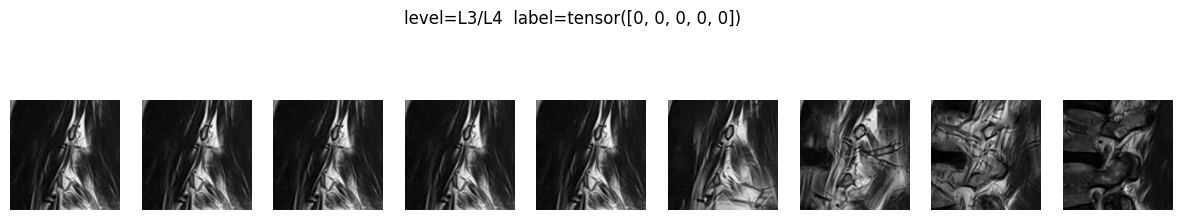

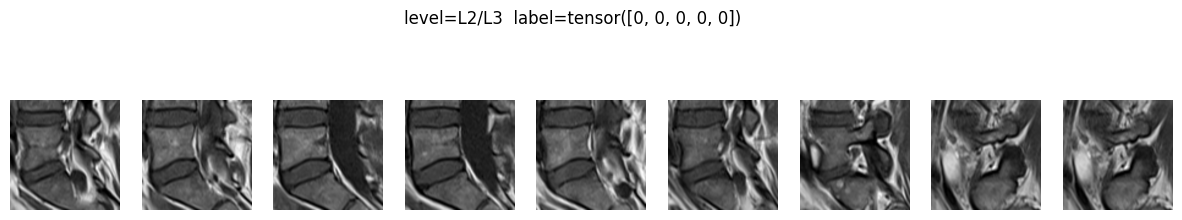

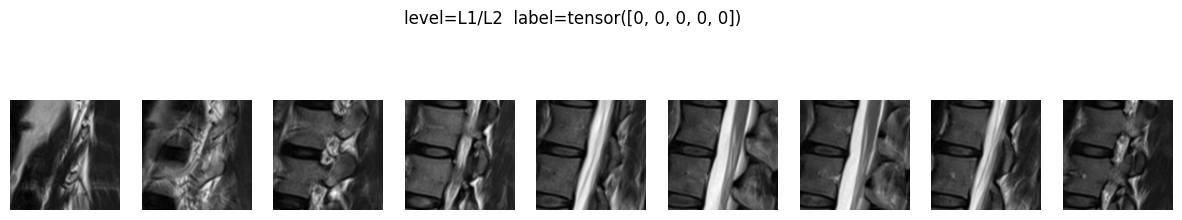

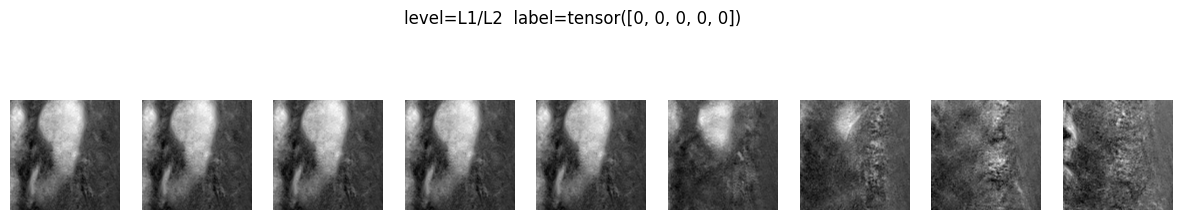

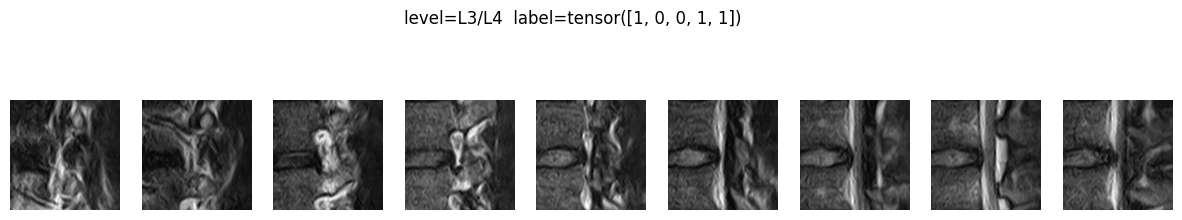

In [21]:
# ROI 시각화 propaation 품질 확인
import torch
import os
import matplotlib.pyplot as plt
import random

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"
files = os.listdir(path)

for f in random.sample(files, 5):

    x = torch.load(os.path.join(path, f))

    imgs = x["image"]

    fig, axs = plt.subplots(1,9, figsize=(15,3))

    for i in range(9):
        axs[i].imshow(imgs[i], cmap="gray")
        axs[i].axis("off")

    plt.suptitle(f"level={x['level']}  label={x['label']}")
    plt.show()

In [23]:
# label Distribution 분석(class imbalance가 심해 loss weighting이 필요함)
import torch
import os
import numpy as np

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"
files = os.listdir(path)

labels = []

for f in files[:20000]:
    x = torch.load(os.path.join(path,f))
    labels.append(x["label"].numpy())

labels = np.stack(labels)

print("shape:", labels.shape)

for i,name in enumerate([
    "canal",
    "left_foraminal",
    "right_foraminal",
    "left_subarticular",
    "right_subarticular"
]):
    valid = labels[:,i]
    valid = valid[valid >= 0]   # ⭐ -1 제거

    print(name, np.bincount(valid))    

/tmp/ipykernel_942088/4149464643.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path,f))


shape: (20000, 5)
canal [18114  1272   614]
left_foraminal [17303  2311   363]
right_foraminal [17248  2306   362]
left_subarticular [15553  2639  1109]
right_subarticular [15504  2768  1049]


In [24]:
print(x.keys())

dict_keys(['image', 'label', 'level', 'coord', 'study_id', 'series_id', 'instance_number', 'cycle_error'])


In [ ]:
## 학습 전략
# Experiment 1 - CNN + LSTM
# slice CNN -> LSTM -> classifier

In [ ]:
# Experiment 2 - Guided Attention(CNN + guided attention + lstm)
# feautere map(CNN) -> coordinate gaussian mask -> attention

In [ ]:
# Experiment 3 - Transformer(CNN + transformer)
# slice feature -> transformer encoder -> classifier

In [ ]:
## 평가 방법
# Accuracy(기본 성능)
# F1(imbalance 데이터라서)
# AUC
# GradCAM(visualization)

In [ ]:
# spine_dataset으로 데이터 나눔
# building study map...
# total studies: 1973
# train studies: 1578
# val studies: 395
# train samples: 281000
# val samples: 70000
# 총 351,783개의 samples
# weight는 imbalance 때문에 normal- 0.1, moderate - 1.0, severe - 2.0으로 함.
# 모델은 ConvNext-Base으로 하려고 했는데, 메모리 부족으로(batch를 줄이는 것보다) ConvNext-Tiny로 수정
# .pt로 진행을 하려고 하는데, 로딩하는 시간과 메모리 부족으로 터져서, .npy파일로 모아 mmap방식을 쓰기로 함.
# mmap_mode="r"은 디스크처럼 내가 지정하는 정보만 골라 가지고 와서 메모리 거의 안씀

In [2]:
import torch

data = torch.load("../outputs/roi_dataset/1000.pt")
print(data["image"].dtype)
print(data["image"].shape)

torch.float16
torch.Size([9, 224, 224])


/tmp/ipykernel_1406/2367569391.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("../outputs/roi_dataset/1000.pt")


In [ ]:
# 그래서 pt를 npy로 변환할 conver_pt_to_npy.py를 돌리고 (351783개의.pt파일을 coord, images, labels, levels npy 파일로 변환)
# spine_dataset.py를 수정하여 experiment1.py를 돌림.

In [ ]:
import numpy as np

N = 351783

images = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/images.npy",
    dtype=np.float16,
    mode="r",
    shape=(N,9,224,224)
)

labels = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/labels.npy",
    dtype=np.int64,
    mode="r",
    shape=(N,5)
)

coords = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/coords.npy",
    dtype=np.float32,
    mode="r",
    shape=(N,2)
)

levels = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/levels.npy",
    dtype=np.int64,
    mode="r",
    shape=(N,)
)

print(images.shape)
print(labels.shape)
print(images[0].shape)
print(labels[0])

(351783, 9, 224, 224)
(351783, 5)


In [ ]:
# VAL ACC: 0.2819068194093067
# VAL F1: 0.12292730466065242
# VAL AUC: 0.49939256896515827
# 시간은 100시간이고, 정확도는 이상해서 수정..
# 라벨에서 심각도 [0, 1, 2]에서 [0]의 샘플이 너무 많아 1/3만 사용하기로 함.
# 스케쥴러 사용